# 휴먼 vs 매크로 행동 데이터 EDA

In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import json
import numpy as np
import yaml
import seaborn as sns
import platform

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [5]:
# 가능한 한글 폰트 출력

# import matplotlib.font_manager as fm

# fonts = sorted(set(f.name for f in fm.fontManager.ttflist))

# _fonts =  []
# for font in fonts:
#     if any(keyword in font.lower() for keyword in ["nanum", "noto", "malgun", "apple", "gothic"]):
#         _fonts.append(font)
#         print(font)

In [6]:
# 노트북 세팅
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

# 한글 폰트 적용

system = platform.system()

if system == "Darwin":  # macOS
    font_candidates = ["Nanum Gothic", "AppleGothic"]
elif system == "Windows":
    font_candidates = ["Malgun Gothic"]
else:  
    font_candidates = ["Nanum Gothic", "DejaVu Sans"]

for _font in font_candidates:
    try:
        plt.rcParams["font.family"] = _font
        print(f"한글 폰트 적용: {_font}")
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False

한글 폰트 적용: Malgun Gothic


## 1. 데이터 준비

In [7]:
# 데이터 경로 설정

ROOT = Path.cwd()

if(ROOT.name != "EDA"):
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

DATA_DIR = Path("../../data/behavior")

print(ROOT)
print(DATA_DIR)

c:\Users\SSAFY\Desktop\ws\free\S14P31A203\services\ai\train\EDA
..\..\data\behavior


In [8]:
feature_config_path = Path("../../configs/feature_config.yaml")

with open(feature_config_path, "r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KR = feature_config["names_ko"]
EXCLUDE_COL = feature_config["exclude"] # trial_id, label, stage, selectedSeats 제외 -> not numberic

CLICK_FEATURES = FEATURE_GROUPS["click"]
MOUSE_FEATURES = FEATURE_GROUPS["mouse"]
KEYBOARD_FEATURES = FEATURE_GROUPS["keyboard"]

BEHAVIOR_FEATURES = [f for group in FEATURE_GROUPS.values() for f in group]

feature_group_map = {
    feature: group
    for group, features in FEATURE_GROUPS.items()
    for feature in features
}

print("행동 feature 개수:", len(BEHAVIOR_FEATURES))

행동 feature 개수: 44


In [9]:
# 행동 데이터 로드

def load_data(data_dir: Path) -> pd.DataFrame:
    """데이터 로드

    Args:
        data_dir (Path): 데이터 디렉토리 경로
    Returns:
        pd.DataFrame: 행동 데이터프레임
    """

    rows: list[dict] = []
    
    for path in sorted(data_dir.glob("trial_*.json")):

        data = json.loads(path.read_text(encoding="utf-8"))
        label = data.get("label", None)

        if(label is None):
            continue

        id = int(data.get("trialId"))
        summary = data.get("summary", {})
        feature = data.get("metrics", {})

        row = {
            "trial_id": id,
            "label": label,
        }

        if isinstance(summary, dict):
            row.update(summary)
        if isinstance(feature, dict):
            row.update(feature)
        
        rows.append(row)
    
    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    return df

df = load_data(DATA_DIR)

print("데이터 개수:", len(df))
display(df.head())


데이터 개수: 324


,trial_id,label,stage,durationMs,clickCount,eventCount,windowCount,selectedSeats,time_to_first_click_ms,time_from_element_visible_to_click_ms,time_from_element_clickable_to_click_ms,inter_click_interval_ms,click_sequence_consistency_score,click_position_repeat_rate,click_offset_from_element_center_px,click_offset_variance_px,double_click_rate,misclick_rate,reclick_rate,pre_click_mousemove_count,pre_click_hover_time_ms,pre_click_scroll_flag,immediate_post_render_click_rate,mouse_total_travel_distance_px,mouse_avg_speed_px_per_ms,mouse_max_speed_px_per_ms,mouse_speed_change_mean,mouse_acceleration_mean,mouse_jerk_mean,mouse_path_straightness_score,mouse_path_curvature_mean,mouse_direction_change_count,mouse_overshoot_flag,mouse_hover_dwell_time_ms,mouse_stop_segment_count,mousemove_event_rate,pre_click_mouse_path_pattern_300ms,pre_click_mouse_path_pattern_500ms,inter_element_move_interval_std_ms,edge_or_fixed_point_visit_rate,time_to_first_keydown_ms,inter_key_interval_ms_mean,inter_key_interval_ms_std,keydown_to_keyup_ms_mean,typing_total_duration_ms,typing_speed_cps,backspace_rate,correction_count,paste_flag,focus_to_submit_ms
0,1,macro,confirmed,2188.7,5,40,8,"[B3, B4]",1523.0,386.880000,386.880000,166.350000,1.000000,0.0,0.930801,0.022615,0.800000,0.000000,0.000000,9.800000,34.080000,0.0,0.8,1736.623385,0.793450,32.367655,7.323334,0.473873,0.064371,0.450931,0.282933,4,0,86.850000,6,9.137844,1147.5px | straight 0.49,1334.3px | straight 0.33,77.765593,0.0,35.3,24.716667,8.346140,19.471429,148.3,47.201618,0.0,0,0,289.6
1,2,human,confirmed,6458.4,9,323,26,"[B5, B4]",851.7,1513.637500,1513.637500,700.800000,0.875000,0.0,28.493302,646.669910,0.444444,0.111111,0.111111,27.444444,246.944444,0.0,0.0,2828.306989,0.437927,10.561944,0.445123,0.052016,0.004934,0.358283,0.206629,58,0,210.584000,20,46.296296,40.9px | straight 0.93,814.6px | straight 0.97,694.574215,0.0,558.8,192.150000,131.387845,117.814286,1152.9,6.071645,0.0,0,0,2887.7
2,3,human,confirmed,5969.8,7,322,23,"[B4, B5]",951.6,1510.433333,1510.433333,836.316667,0.833333,0.0,26.679236,122.389226,0.285714,0.142857,0.000000,33.000000,220.442857,0.0,0.0,1969.649553,0.329936,6.833317,0.267882,0.031645,0.003265,0.449383,0.248568,74,0,199.658333,12,50.587959,133.3px | straight 0.97,702.2px | straight 0.98,704.293103,0.0,622.1,153.960000,56.480779,127.083333,769.8,7.794232,0.0,0,0,2363.3
3,4,human,confirmed,5535.6,5,253,23,"[B4, B5]",1731.0,1456.900000,1456.900000,951.050000,1.000000,0.0,45.429430,1404.299006,0.200000,0.000000,0.000000,33.400000,207.200000,0.0,0.0,1939.123226,0.350300,5.180723,0.306412,0.036340,0.003624,0.451466,0.138800,35,0,193.380000,9,42.452489,81.9px | straight 0.94,593.8px | straight 0.99,674.567448,0.0,523.9,161.580000,87.159358,147.133333,807.9,7.426662,0.0,0,0,2125.2
4,5,human,confirmed,5874.0,6,276,22,"[B4, B5]",1533.5,1529.080000,1529.080000,868.060000,0.800000,0.0,29.553804,374.657158,0.333333,0.166667,0.000000,29.500000,178.900000,0.0,0.0,2085.415223,0.355025,4.651163,0.269461,0.032168,0.003403,0.428887,0.206689,47,0,175.150000,13,43.752128,92.9px | straight 0.98,626.0px | straight 0.99,726.495620,0.0,468.5,156.800000,51.045117,129.183333,784.0,7.653061,0.0,0,0,2587.7


## 2. 데이터 전처리

In [10]:
# pre_click_mouse_path 문자열 패턴에서 거리와 직선성 추출

import pandas as pd

def add_pre_click_path_features(df: pd.DataFrame) -> None:
    """pre_click_mouse_path 문자열 패턴에서 거리와 직선성을 추출하여 feature로 추가
    
    Args:
        df (pd.DataFrame): 행동 데이터프레임
    """

    for sec in [300, 500]:
        col = f"pre_click_mouse_path_pattern_{sec}ms"

        if col not in df.columns:
            continue

        parts = (
            df[col]
            .fillna("")
            .astype(str)
            .str.split("|", n=1, expand=True)
        )

        distance_text = (
            parts[0]
            .str.replace("px", "", regex=False)
            .str.strip()
        )

        straightness_text = (
            parts[1]
            .str.replace("straight", "", regex=False)
            .str.strip()
        )

        distance_col = f"pre_click_path_{sec}ms_total_distance_px"
        straightness_col = f"pre_click_path_{sec}ms_straightness"

        insert_idx = df.columns.get_loc(col)

        distance_value = pd.to_numeric(distance_text, errors="coerce")
        straightness_value = pd.to_numeric(straightness_text, errors="coerce")

        df.drop(columns=[col], inplace=True)

        df.insert(insert_idx, distance_col, distance_value)
        df.insert(insert_idx + 1, straightness_col, straightness_value)
        
add_pre_click_path_features(df)

## 3. 기본 분석

In [11]:
# 행동 데이터 통계 요약

def feature_summary(df: pd.DataFrame) -> pd.DataFrame:
    """행동 데이터 통계 정보 요약 & 휴먼, 매크로 비교
    
    Args:
        df (pd.DataFrame): 행동 데이터프레임

    Returns:
        pd.DataFrame: 행동 feature 통계 요약 데이터프레임
    """

    n_rows = max(1, int(df.shape[0]))

    rows: list[dict] = []

    for feature in df.columns:
        if feature in EXCLUDE_COL:
            continue
        s = df[feature].dropna()

        rows.append(
            {
                "group": feature_group_map.get(feature, "summary"),
                "feature": feature,
                "feature_ko": FEATURE_NAME_KR.get(feature),
                "count": int(s.shape[0]),
                "mean": float(s.mean()) if s.shape[0] else np.nan,
                "std": float(s.std()) if s.shape[0] else np.nan,
                "min": float(s.min()) if s.shape[0] else np.nan,
                "max": float(s.max()) if s.shape[0] else np.nan,
            }
        )

    return pd.DataFrame(rows)

human_df = df[df["label"] == "human"]
macro_df = df[df["label"] == "macro"]

human_summary = feature_summary(human_df)
macro_summary = feature_summary(macro_df)


In [12]:
# 행동 데이터 요약 결합(휴먼, 매크로) 및 SMD 계산 

levels = ["huge", "very_large", "large", "medium", "small"]

def merge_df(human_df: pd.DataFrame, macro_df: pd.DataFrame) -> tuple[pd.DataFrame, list[pd.DataFrame]]:
    """행동 데이터프레임 결합

    Args:
        human_df (pd.DataFrame): 휴먼 행동 데이터프레임
        macro_df (pd.DataFrame): 매크로 행동 데이터프레임 

    Returns:
        tuple[pd.DataFrame, list[pd.DataFrame]]: 결합된 비교 데이터프레임 / SMD level별 행동 데이터프레임 리스트
    """

    compare_summary = human_df.merge(
    macro_df,
    on=["feature_ko", "feature", "group"],
    suffixes=("_human", "_macro")
    )

    compare_summary["mean_diff"] = (
        compare_summary["mean_human"] - compare_summary["mean_macro"]
    )

    compare_summary["pooled_std"] = np.sqrt(
        (compare_summary["std_macro"]**2 + compare_summary["std_human"]**2) / 2
    )

    compare_summary["SMD"] = (
        compare_summary["mean_diff"] / compare_summary["pooled_std"]
    )

    compare_summary["abs_SMD"] = compare_summary["SMD"].abs()

    compare_summary = compare_summary[
        [
            "group",
            "feature_ko",
            "SMD",
            "mean_human",
            "mean_macro",
            "min_human",
            "min_macro",
            "max_human",
            "max_macro",
            "count_human",
            "count_macro",
            "abs_SMD",
            "feature"
        ]
    ]

    compare_summary["SMD_level"] = pd.cut(
        compare_summary["abs_SMD"],
        bins=[-float("inf"), 0.2, 0.5, 0.8, 1.5, 3.0, float("inf")],
        labels=["negligible", "small", "medium", "large", "very_large", "huge"]
    )

    summary_df: list[pd.DataFrame] = []
    for level in levels:
        summary_df.append(compare_summary[compare_summary["SMD_level"] == level])

    return compare_summary, summary_df

compare_summary, summary_df = merge_df(human_summary, macro_summary)

feature_smd_map = (
    compare_summary
    .set_index("feature")[["SMD_level", "abs_SMD"]]
    .apply(lambda row: (row["SMD_level"], row["abs_SMD"]), axis=1)
    .to_dict()
)

print("휴먼 데이터 수 : ", human_df.shape[0])
print("매크로 데이터 수 : ", macro_df.shape[0])


휴먼 데이터 수 :  160
매크로 데이터 수 :  164


In [13]:
print(feature_smd_map)

{'durationMs': ('very_large', 1.557411603685718), 'clickCount': ('large', 0.8124978708154973), 'eventCount': ('huge', 4.559427261942528), 'windowCount': ('very_large', 1.786112800580925), 'time_to_first_click_ms': ('negligible', 0.11226262058388929), 'time_from_element_visible_to_click_ms': ('very_large', 1.6783659918608007), 'time_from_element_clickable_to_click_ms': ('very_large', 1.6783659918608007), 'inter_click_interval_ms': ('very_large', 1.5599535911363605), 'click_sequence_consistency_score': ('medium', 0.7479919594146893), 'click_position_repeat_rate': ('negligible', 0.19325780442685891), 'click_offset_from_element_center_px': ('very_large', 1.6181016033942703), 'click_offset_variance_px': ('small', 0.44275075645976203), 'double_click_rate': ('large', 0.9068934762472892), 'misclick_rate': ('large', 0.9169026795824046), 'reclick_rate': ('small', 0.2420891179342344), 'pre_click_mousemove_count': ('huge', 4.677008273531799), 'pre_click_hover_time_ms': ('medium', 0.733573005421837

`(comment)`

SMD (Standardized Mean Difference)


`두 집단의 평균 차이를 표준편차 단위로 변환한 값`
- 현재 태스크에서는 human과 macro의 평균 행동 차이를 비교하는 지표로 사용  

<br>

`SMD > 0` : human > macro

`SMD < 0` : human < macro


<br>
abs_SMD가 클수록 두 집단 차이가 큰 feature 후보
(단, SMD는 평균 차이 중심 지표이므로 분포 겹침, 이상치, 고정 패턴은 boxplot으로 함께 확인 필요) <br> <br>



`abs_SMD 값에 따른 평가 기준`


|  abs_SMD 범위 | level      | 해석         |
| ----------: | ---------- | ---------- |
|     `< 0.2` | negligible | 거의 차이 없음   |
| `0.2 ~ 0.5` | small      | 작은 차이      |
| `0.5 ~ 0.8` | medium     | 중간 차이      |
| `0.8 ~ 1.5` | large      | 큰 차이       |
| `1.5 ~ 3.0` | very_large | 매우 큰 차이    |
|    `>= 3.0` | huge       | 극단적으로 큰 차이 |


In [14]:
print("\n행동 feature 통계 요약 비교:")

print(f"\n1. {levels[0]}")
display(summary_df[0].sort_values("abs_SMD", ascending=False))


행동 feature 통계 요약 비교:

1. huge


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
31,mouse,mousemove 빈도,6.214009,43.254905,7.761892,25.119496,3.394779,65.943979,13.349947,160,164,6.214009,mousemove_event_rate,huge
15,click,클릭 전 이동 수,4.677008,27.101471,8.240244,13.000000,4.000000,40.166667,13.200000,160,164,4.677008,pre_click_mousemove_count,huge
2,summary,전체 이벤트 수,4.559427,310.531250,52.591463,163.000000,30.000000,692.000000,90.000000,160,164,4.559427,eventCount,huge
27,mouse,방향 전환 수,3.587177,56.025000,5.060976,20.000000,4.000000,177.000000,6.000000,160,164,3.587177,mouse_direction_change_count,huge
32,mouse,300ms 경로 총거리,-3.468541,68.915753,742.831343,1.000000,0.000000,271.900000,1313.300000,146,134,3.468541,pre_click_path_300ms_total_distance_px,huge


(comment)

`huge` 그룹은 `|SMD| > 3.0` 이상 그룹으로 `휴먼과 매크로의 차이가 매우 큰 feature`

click, summary 그룹이 포함되어있지만 이는 모두 마우스 움직임에 관한 지표 (클릭 전 이동 수, 전체 이벤트 수)

`전체적으로 휴먼이 마우스 이동거리가 많고, 매크로는 이동거리는 짧지만 짧은 시간안에 빠르게 이동함`

`해당 feature는 로직으로 필터링하거나 ML 모델의 핵심 feature 후보로 선정` (확정은 boxplot 분석 후 파일로 저장)



In [15]:
print(f"\n2. {levels[1]}")
display(summary_df[1].sort_values("abs_SMD", ascending=False))


2. very_large


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
30,mouse,정지 구간 수,2.118048,15.250000,7.560976,7.000000,5.000000,40.000000,10.000000,160,164,2.118048,mouse_stop_segment_count,very_large
3,summary,이벤트 집계 구간 수,1.786113,26.193750,14.463415,17.000000,7.000000,69.000000,27.000000,160,164,1.786113,windowCount,very_large
34,mouse,500ms 경로 총거리,-1.733002,449.370513,932.501829,3.000000,107.300000,1141.600000,1340.300000,156,164,1.733002,pre_click_path_500ms_total_distance_px,very_large
5,click,노출 후 클릭,1.678366,1832.224329,916.971585,1119.720000,295.040000,6103.450000,1838.760000,160,164,1.678366,time_from_element_visible_to_click_ms,very_large
6,click,활성 후 클릭,1.678366,1832.224329,916.971585,1119.720000,295.040000,6103.450000,1838.760000,160,164,1.678366,time_from_element_clickable_to_click_ms,very_large
10,click,중심 오차,1.618102,61.981601,0.930801,15.000771,0.930801,300.236799,0.930801,160,164,1.618102,click_offset_from_element_center_px,very_large
7,click,클릭 간격,1.559954,1167.738287,618.067226,647.160000,128.900000,2576.650000,1332.475000,160,164,1.559954,inter_click_interval_ms,very_large
0,summary,페이지 체류 시간,1.557412,6826.435000,4056.154268,4636.500000,1957.800000,17895.600000,7161.700000,160,164,1.557412,durationMs,very_large


(comment)

`very_large` 그룹은 `1.5 <= |SMD| < 3.0` 그룹으로 `휴먼과 매크로의 차이가 큰 feature`


매크로가 휴먼보다 `노출, 활성화 후 클릭시간이 빠름` 그리고 `버튼의 정확히 가운데를 누르는 경향`이 있음 (Playwright : DOM, 요소 기반 자동화)

단, 중심 오차와 클릭 간격은 시퀀스적으로 일정한 지가 더 중요한 지표가 됨 (시퀀스 분석 필요)

`huge, very_large 그룹을 봤을 때, summary 등 요약 정보는 휴먼과 매크로의 차이가 비교적 확실한 것을 알 수 있음` (로직 기반 필터링)


In [16]:
print(f"\n3. {levels[2]}")
display(summary_df[2].sort_values("abs_SMD", ascending=False))


3. large


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
36,mouse,이동 간격 표준편차,1.435645,920.615399,416.734095,412.409198,56.723981,2574.095837,926.997811,160,164,1.435645,inter_element_move_interval_std_ms,large
19,mouse,총 이동 거리,1.418840,2583.859984,1755.782078,1597.397965,1355.864289,6773.917091,1882.728275,160,164,1.418840,mouse_total_travel_distance_px,large
18,click,즉시 클릭 비율,-1.412204,0.076803,0.357317,0.000000,0.000000,0.200000,0.800000,160,164,1.412204,immediate_post_render_click_rate,large
47,keyboard,포커스 후 확인,1.323673,2693.134375,1339.606098,-3285.400000,227.700000,6878.000000,2935.300000,160,164,1.323673,focus_to_submit_ms,large
22,mouse,속도 변화,-1.243348,0.389055,3.949214,0.234866,0.439956,0.665298,18.195275,160,164,1.243348,mouse_speed_change_mean,large
25,mouse,경로 직선성,-1.022679,0.384146,0.453877,0.145254,0.326004,0.534125,0.489907,160,164,1.022679,mouse_path_straightness_score,large
13,click,오클릭 비율,0.916903,0.060789,0.000000,0.000000,0.000000,0.375000,0.000000,160,164,0.916903,misclick_rate,large
40,keyboard,키 간격 표준편차,0.911980,136.777219,42.875591,12.416698,2.933712,1224.103056,111.526932,160,164,0.911980,inter_key_interval_ms_std,large
12,click,더블클릭 비율,-0.906893,0.233800,0.430488,0.000000,0.000000,0.500000,0.800000,160,164,0.906893,double_click_rate,large
20,mouse,평균 속도,-0.818369,0.385598,0.477972,0.188876,0.261017,0.695574,0.793450,160,164,0.818369,mouse_avg_speed_px_per_ms,large


(comment)

`large` 그룹은 `0.8 <= |SMD| < 1.5` 그룹

편차의 SMD는 비교적 덜 중요하고, 이동거리, 속도와 관련된 비교는 huge, very_large 그룹에서도 드러남

`large 그룹에서 주목할 점은 마우스의 이동이 직선적이고, 클릭 수가 일정한 경향이 강하다는 점`

키보드 feature의 경우는 수집 구간이 한정적이거나 없고, 마우스 feature에 비해 강한 특성이 덜 들어나는 경향이 있음


In [17]:
print(f"\n4. {levels[3]}")
display(summary_df[3].sort_values("abs_SMD", ascending=False))


4. medium


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
43,keyboard,초당 입력 수,-0.791100,7.385540,12.960541,2.009747,4.230118,16.825575,66.100094,160,164,0.791100,typing_speed_cps,medium
38,keyboard,첫 키 입력 시간,0.771159,489.486250,112.185366,-4822.500000,21.000000,2403.300000,254.600000,160,164,0.771159,time_to_first_keydown_ms,medium
26,mouse,경로 곡률,-0.762915,0.197835,0.316241,0.103980,0.079371,0.373504,0.994178,160,164,0.762915,mouse_path_curvature_mean,medium
8,click,순서 일관성,-0.747992,0.951704,1.000000,0.666667,1.000000,1.000000,1.000000,160,164,0.747992,click_sequence_consistency_score,medium
16,click,클릭 전 hover,0.733573,253.144239,172.740976,120.371429,22.020000,631.183333,456.120000,160,164,0.733573,pre_click_hover_time_ms,medium
44,keyboard,백스페이스 비율,0.708017,0.052586,0.000000,0.000000,0.000000,0.533333,0.000000,160,164,0.708017,backspace_rate,medium
42,keyboard,총 입력 시간,0.629351,1382.857500,754.500610,356.600000,105.900000,11180.200000,1654.800000,160,164,0.629351,typing_total_duration_ms,medium
21,mouse,최대 속도,-0.605013,10.422780,18.688735,3.932809,4.432495,26.269096,193.979632,160,164,0.605013,mouse_max_speed_px_per_ms,medium
45,keyboard,수정 횟수,0.551337,0.787500,0.000000,0.000000,0.000000,16.000000,0.000000,160,164,0.551337,correction_count,medium
28,mouse,오버슈트 여부,0.517512,0.118750,0.000000,0.000000,0.000000,1.000000,0.000000,160,164,0.517512,mouse_overshoot_flag,medium


(comment)

`medium` 그룹은 `0.5 <= |SMD| < 0.8` 그룹


마우스 이동 거리, 속도, 클릭 속도 등과 관련된 feature 중 상위 그룹에 미포함된 feature 포함

비교적 덜 관계있었던 keyboard feature도 cohen 기준 지표에 따르면 높은 분리도를 나타내는 feature임을 알 수 있음 (휴먼 vs 매크로)


In [18]:
print(f"\n5. {levels[4]}")
display(summary_df[4].sort_values("abs_SMD", ascending=False))


5. small


,group,feature_ko,SMD,mean_human,mean_macro,min_human,min_macro,max_human,max_macro,count_human,count_macro,abs_SMD,feature,SMD_level
35,mouse,500ms 경로 직선성,0.451706,0.878910,0.774024,0.190000,0.330000,1.000000,1.000000,156,164,0.451706,pre_click_path_500ms_straightness,small
11,click,오차 분산,0.442751,12729.069166,0.022615,31.173682,0.022615,191714.716247,0.022615,160,164,0.442751,click_offset_variance_px,small
23,mouse,가속도 변화,-0.423517,0.047589,0.247701,0.027401,0.020630,0.090432,7.763762,160,164,0.423517,mouse_acceleration_mean,small
29,mouse,평균 dwell,-0.363607,208.506366,234.549692,84.116667,78.477778,401.065000,497.627273,160,164,0.363607,mouse_hover_dwell_time_ms,small
41,keyboard,키 누름 시간,0.356609,129.399510,112.578136,89.925000,13.614286,189.013333,260.300000,160,164,0.356609,keydown_to_keyup_ms_mean,small
14,click,재클릭 비율,0.242089,0.004936,0.000000,0.000000,0.000000,0.250000,0.000000,160,164,0.242089,reclick_rate,small


(comment)

`small` 그룹은 `0.2 <= |SMD| < 0.5` 그룹


### 3-1 데이터 분포 시각화 (박스 플롯)

(comment)

- 우선 순위가 높은 huge, very_large 그룹의 feature들이 `실제로 휴먼과 매크로에 따라 분리가 잘되는 지` boxplot으로 확인
- `이상치, 결측치 때문에 SMD level이 잘못된 것은 아닌지 확인`

In [19]:
# SMD 기준 정렬

# abs_SMD 기준 feature 순서
smd_feature_order = (
    compare_summary.sort_values("abs_SMD", ascending=False)["feature"].tolist()
)

# feature별 SMD 순위
smd_rank = {
    feature: rank
    for rank, feature in enumerate(smd_feature_order)
}

# FEATURE_GROUPS는 유지하고, 그룹 내부만 SMD 순서로 정렬
FEATURE_GROUPS_SORTED = {
    group: sorted(
        features,
        key=lambda feature: smd_rank.get(feature, float("inf"))
    )
    for group, features in FEATURE_GROUPS.items()
}

In [20]:
N_COLS = 3
N_FEATURES = 6
MAX_STRIP_PER_LABEL = 300

def draw_boxplot(group: str, features: list[str]) -> None:
    """행동 feature 그룹별 boxplot 그리기
    
    Args:
        group (str): feature 그룹명
        features (list[str]): feature 이름 리스트
    """

    features =  [feature for feature in features if feature not in EXCLUDE_COL]

    if not features:
        print("skip:", group)
        return
    
    for start in range(0, len(features), N_FEATURES):
        subset = features[start: start + N_FEATURES]

        rows = int(np.ceil(len(subset) / N_COLS))

        fig, axes = plt.subplots(rows, N_COLS, figsize=(16, 4.6 * rows))

        axes = np.array(axes).reshape(rows, N_COLS)

        for i, feature in enumerate(subset):
            r = i // N_COLS
            c = i % N_COLS
            ax = axes[r, c]

            s = pd.to_numeric(df[feature], errors="coerce")

            plot_df = pd.DataFrame(
                {
                    "label": df["label"],
                    "value": s,
                }
            ).dropna()

            feature_ko = FEATURE_NAME_KR.get(feature, feature)

            if plot_df.empty:
                ax.set_title(f"[ {feature_ko} ]\n [ {feature} ]")
                ax.axis("off")
                continue

            sns.boxplot(
                data=plot_df,
                x="label",
                y="value",
                hue="label",
                order=["human", "macro"],
                hue_order=["human", "macro"],
                legend=False,
                dodge=False,
                ax=ax,
                fliersize=2,
            )

            strip_parts = []

            for label in ["human", "macro"]:
                part = plot_df[plot_df["label"] == label]

                if part.empty:
                    continue

                strip_parts.append(
                    part.sample(
                        min(len(part), MAX_STRIP_PER_LABEL),
                        random_state=42,
                    )
                )

            if strip_parts:
                strip_df = pd.concat(strip_parts, ignore_index=True)

                sns.stripplot(
                    data=strip_df,
                    x="label",
                    y="value",
                    ax=ax,
                    color="black",
                    alpha=0.25,
                    size=2,
                    jitter=0.22,
                )

            q_low = plot_df["value"].quantile(0.01)
            q_high = plot_df["value"].quantile(0.99)
            if q_high > q_low:
                ax.set_ylim(q_low, q_high)

            ax.set_title(f"[ {feature_ko} ] [ {feature_smd_map.get(feature, (None, None))[0]} ] [ {feature_smd_map.get(feature, (None, None))[1]:.2f} ]\n[ {feature} ]")
            ax.set_xlabel("")
            ax.set_ylabel("")

        total_axes = rows * N_COLS

        for j in range(len(subset), total_axes):
            r = j // N_COLS
            c = j % N_COLS
            axes[r, c].axis("off")

        fig.suptitle(
            f"Human vs Macro [{group}] Boxplots",
            y=1.02,
            fontsize=14,
        )

        plt.tight_layout()
        plt.show()

groups = []
features_list = []
for group, features in FEATURE_GROUPS_SORTED.items():
    groups.append(group)
    features_list.append(features)

print("Number of groups:", len(groups))

Number of groups: 3



1. 그룹: click


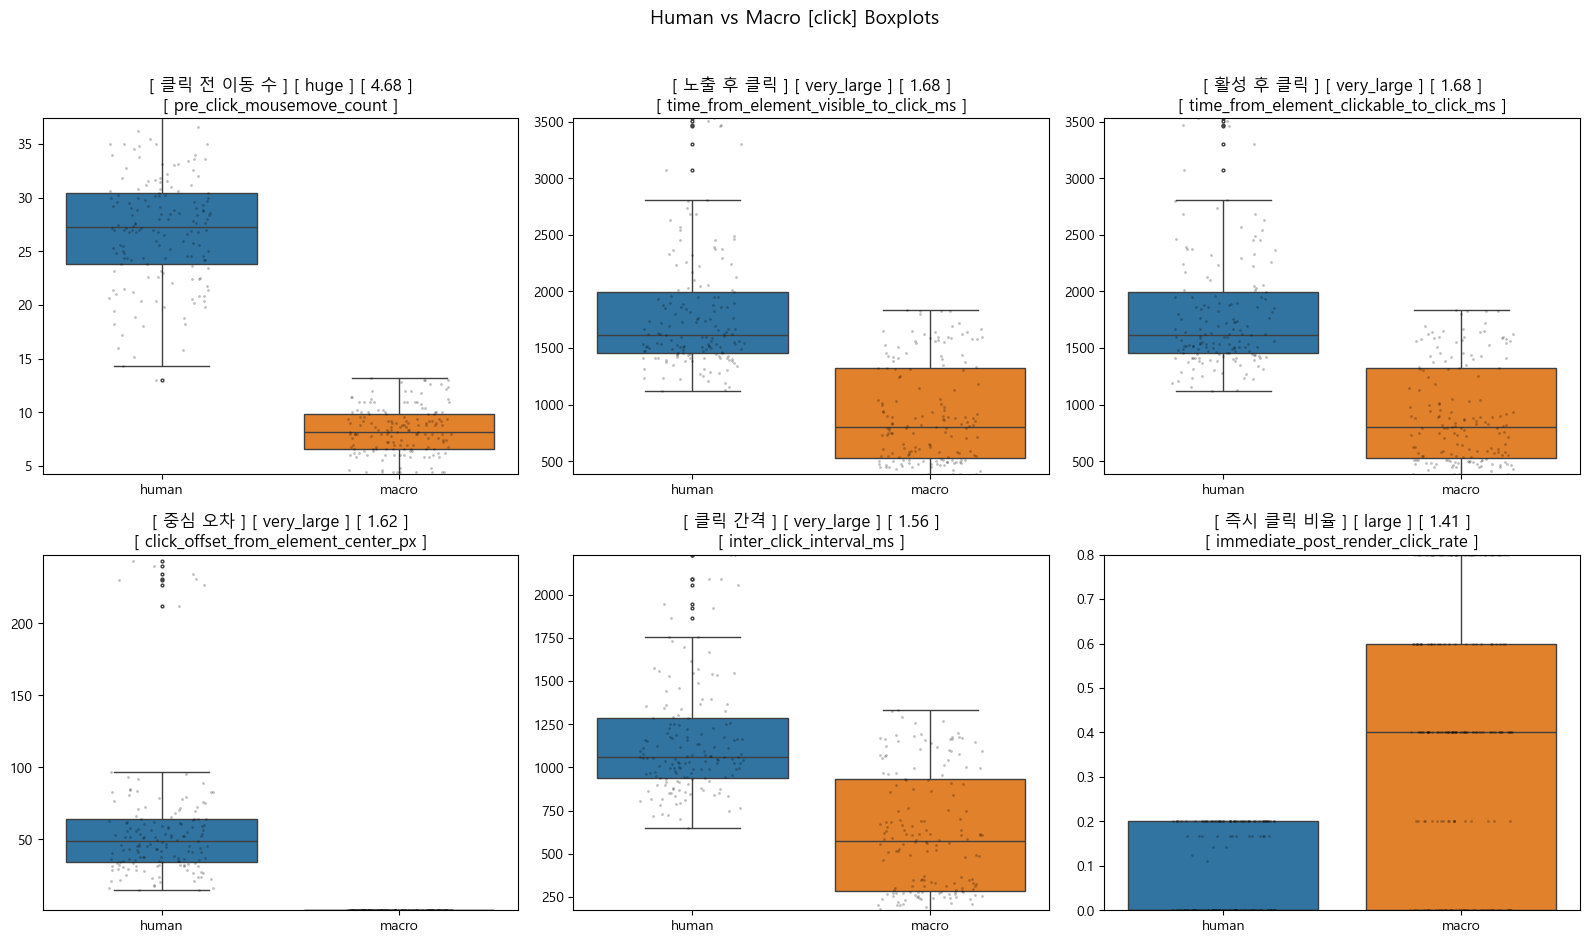

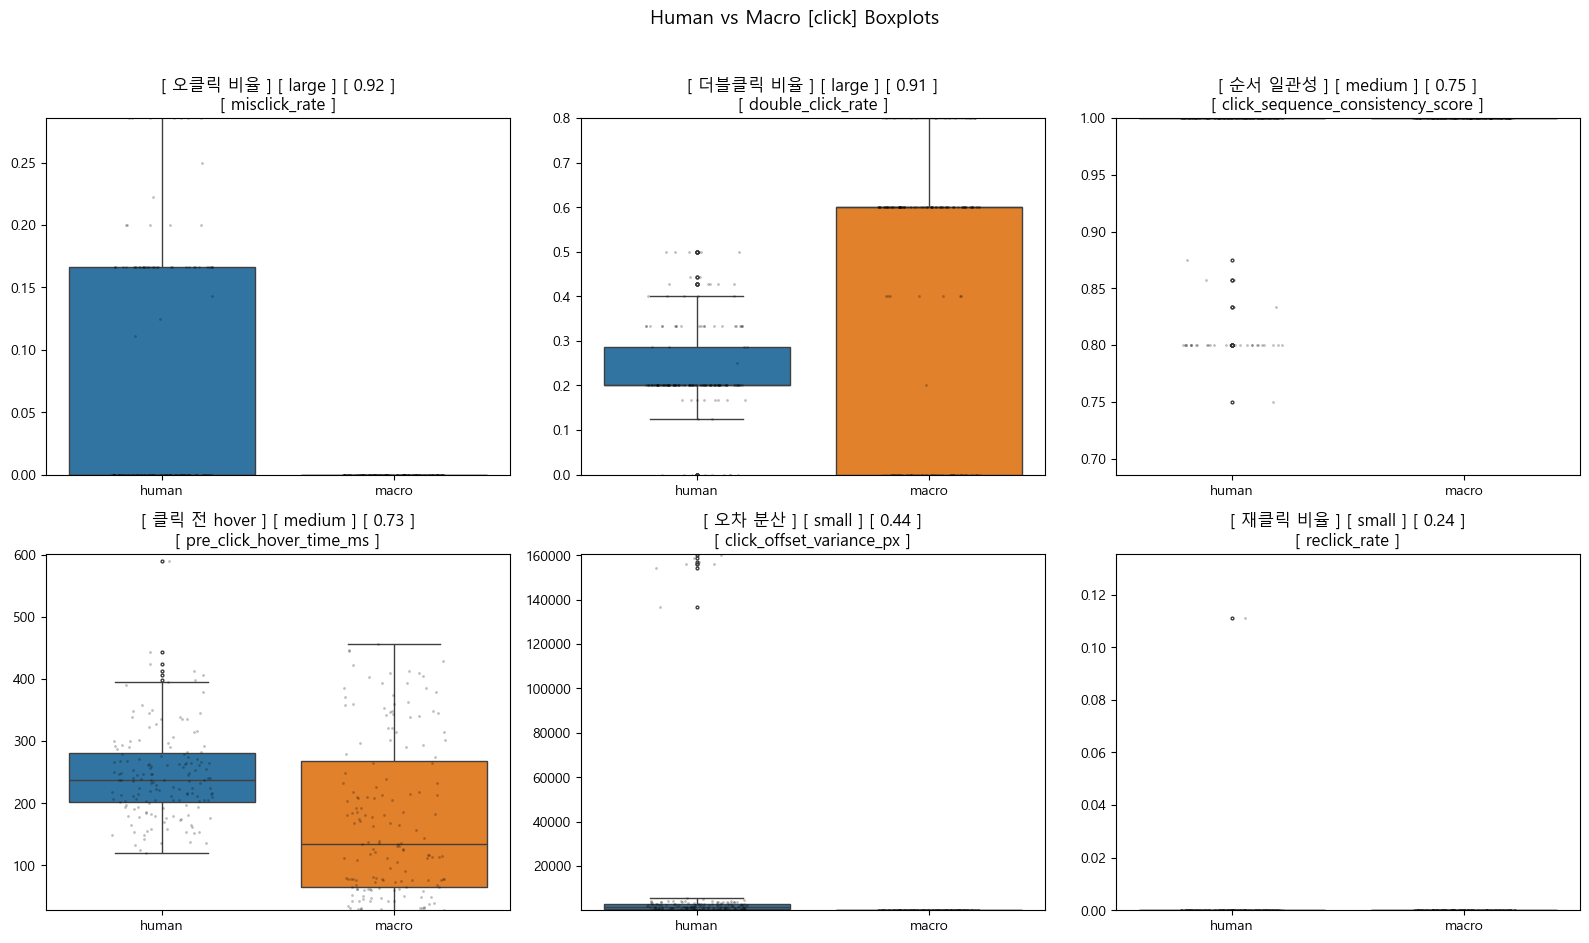

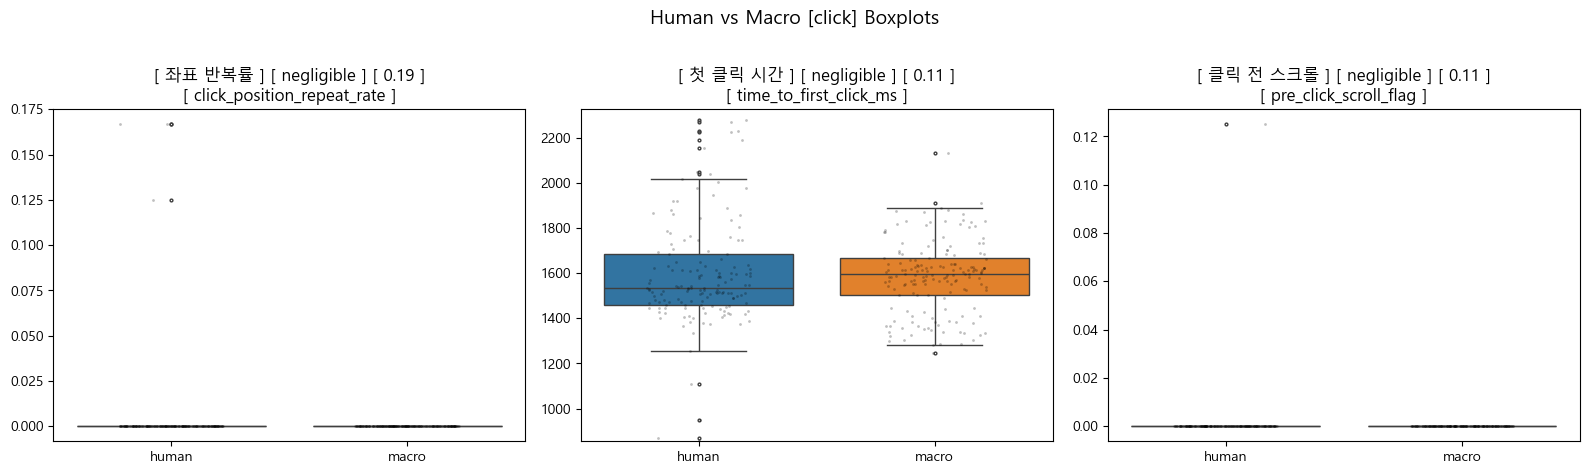

In [21]:
print("\n1. 그룹:", groups[0])
draw_boxplot(groups[0], features_list[0])

(comment)

클릭 간격은 sequence로 수집해야 의미있고, 웹 로딩 시간에 좌우되는 경향이 있어서 제외


2. 그룹: mouse


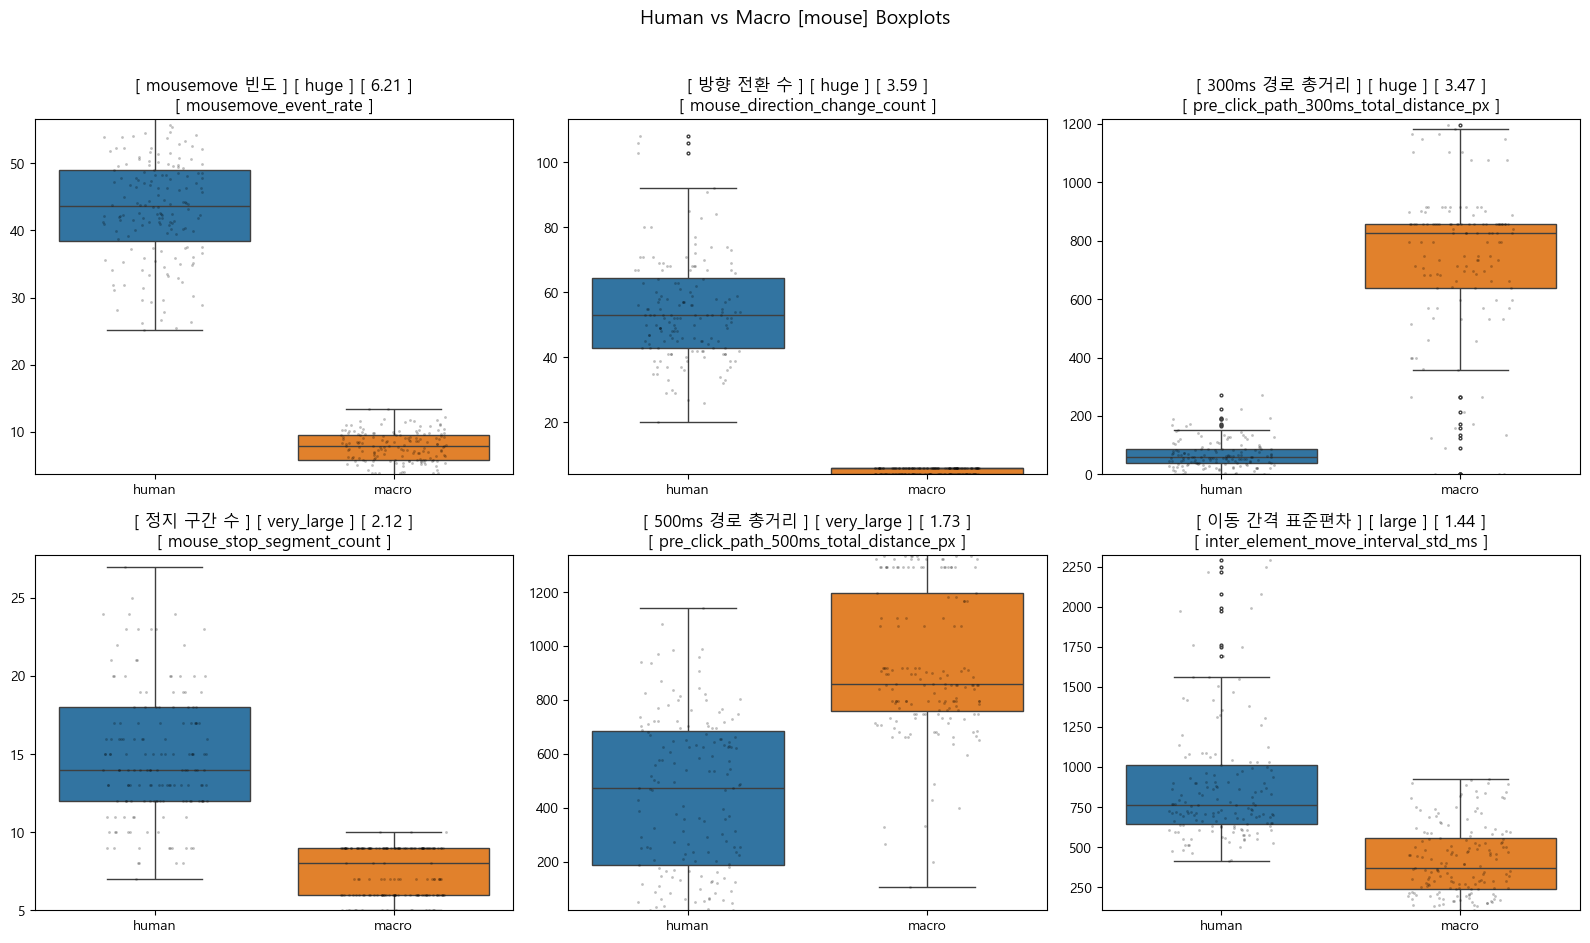

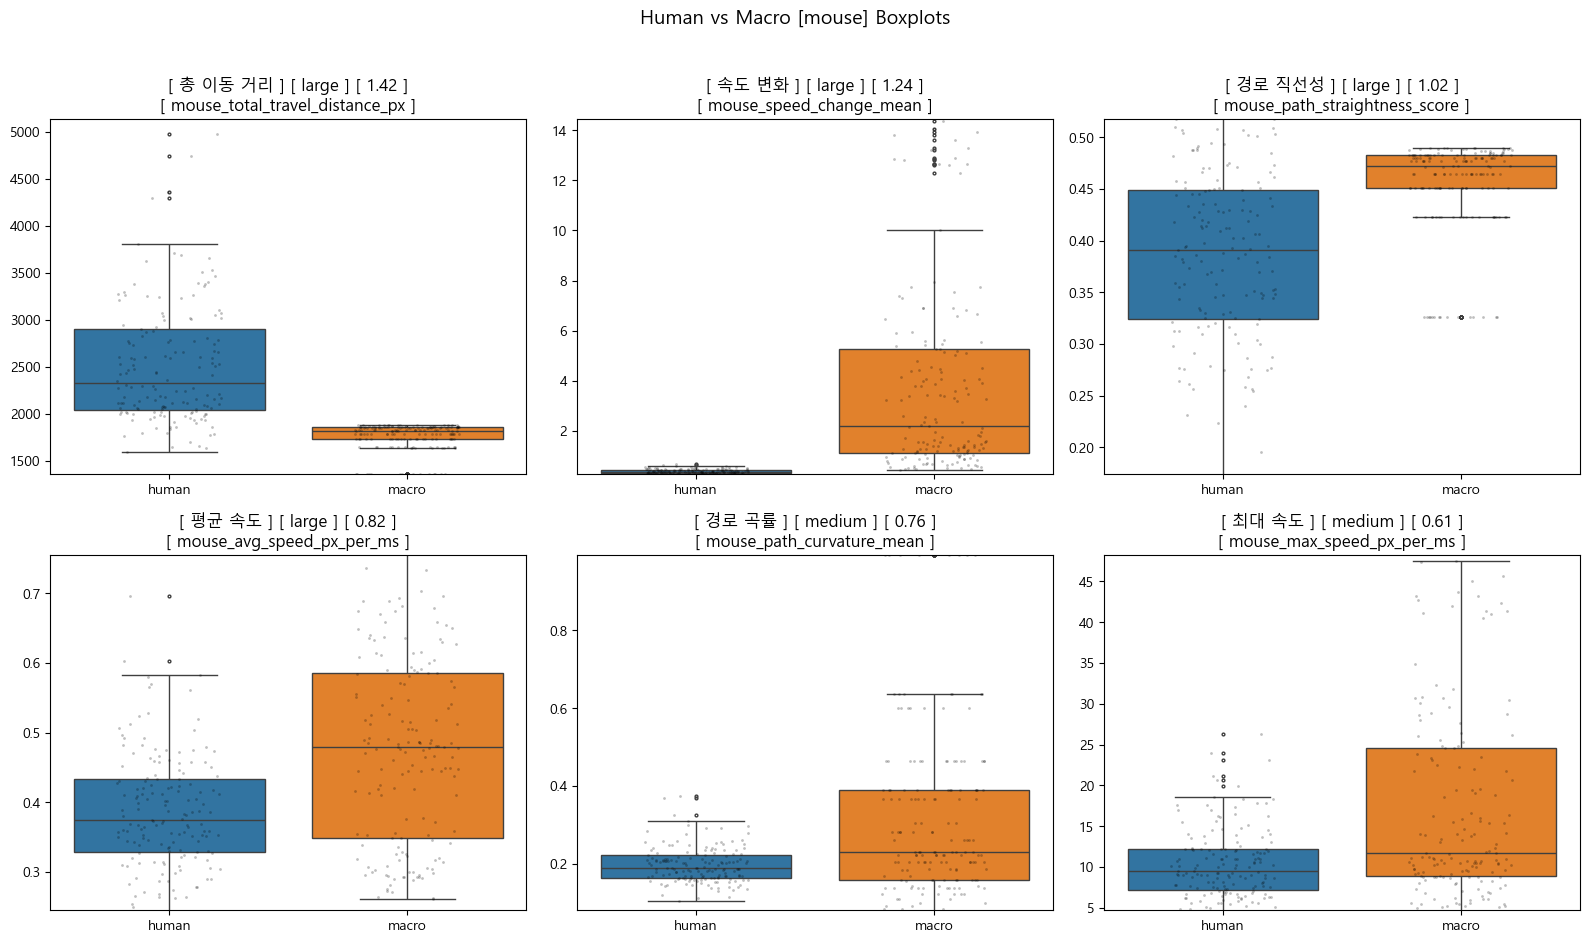

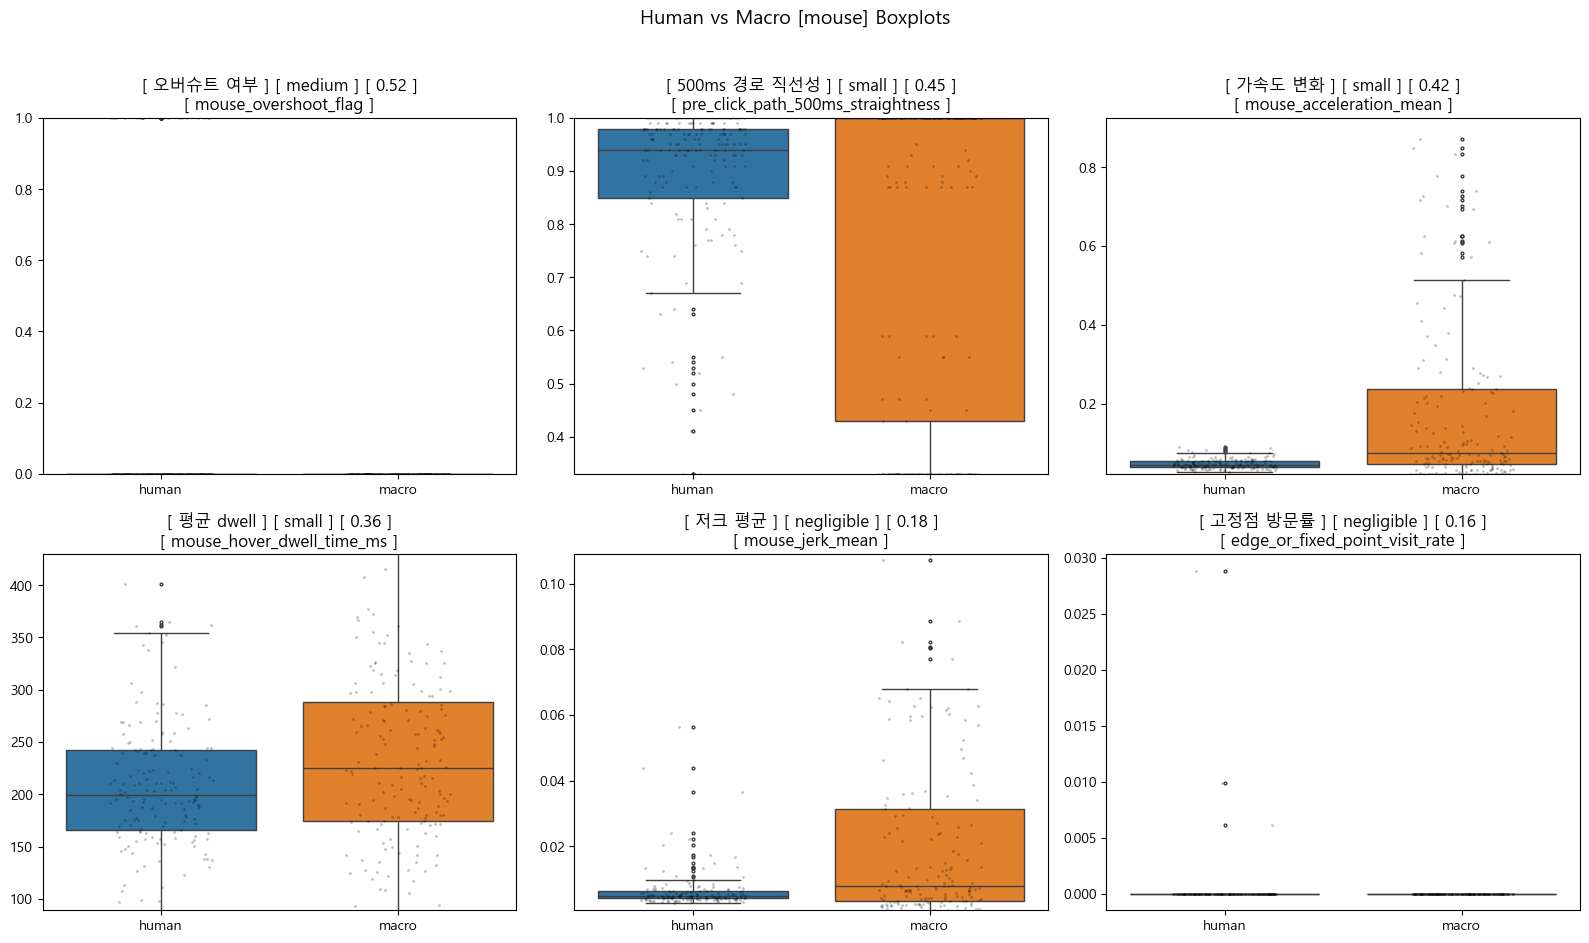

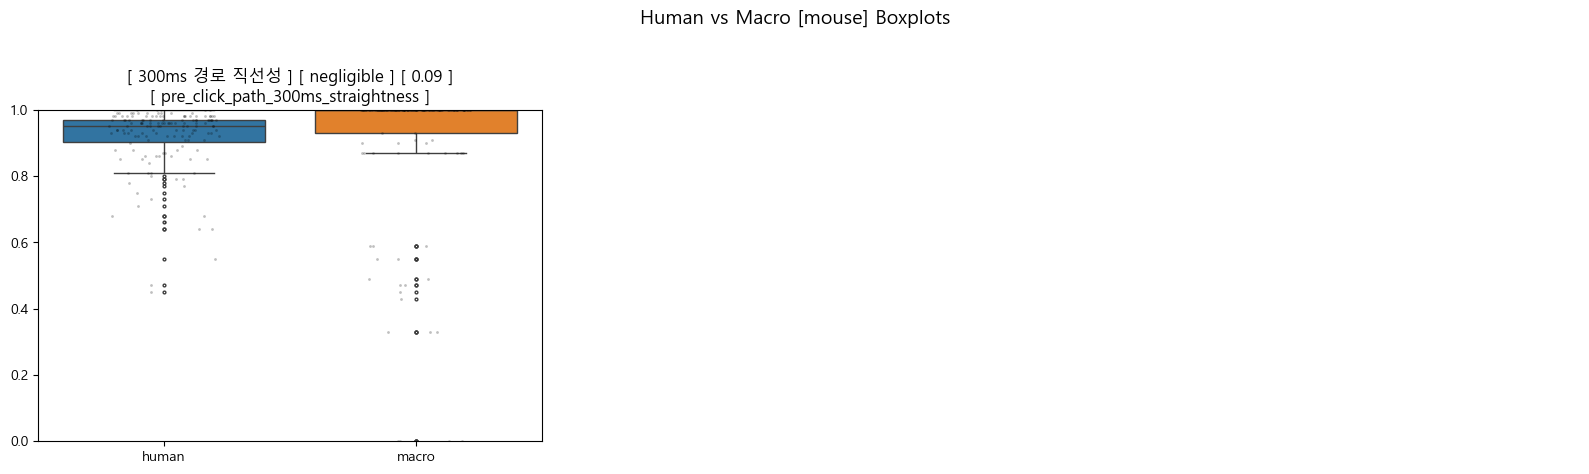

In [22]:
print("\n2. 그룹:", groups[1])
draw_boxplot(groups[1], features_list[1])

(comment)

huge, very_large 그룹 분리도 정확


3. 그룹: keyboard


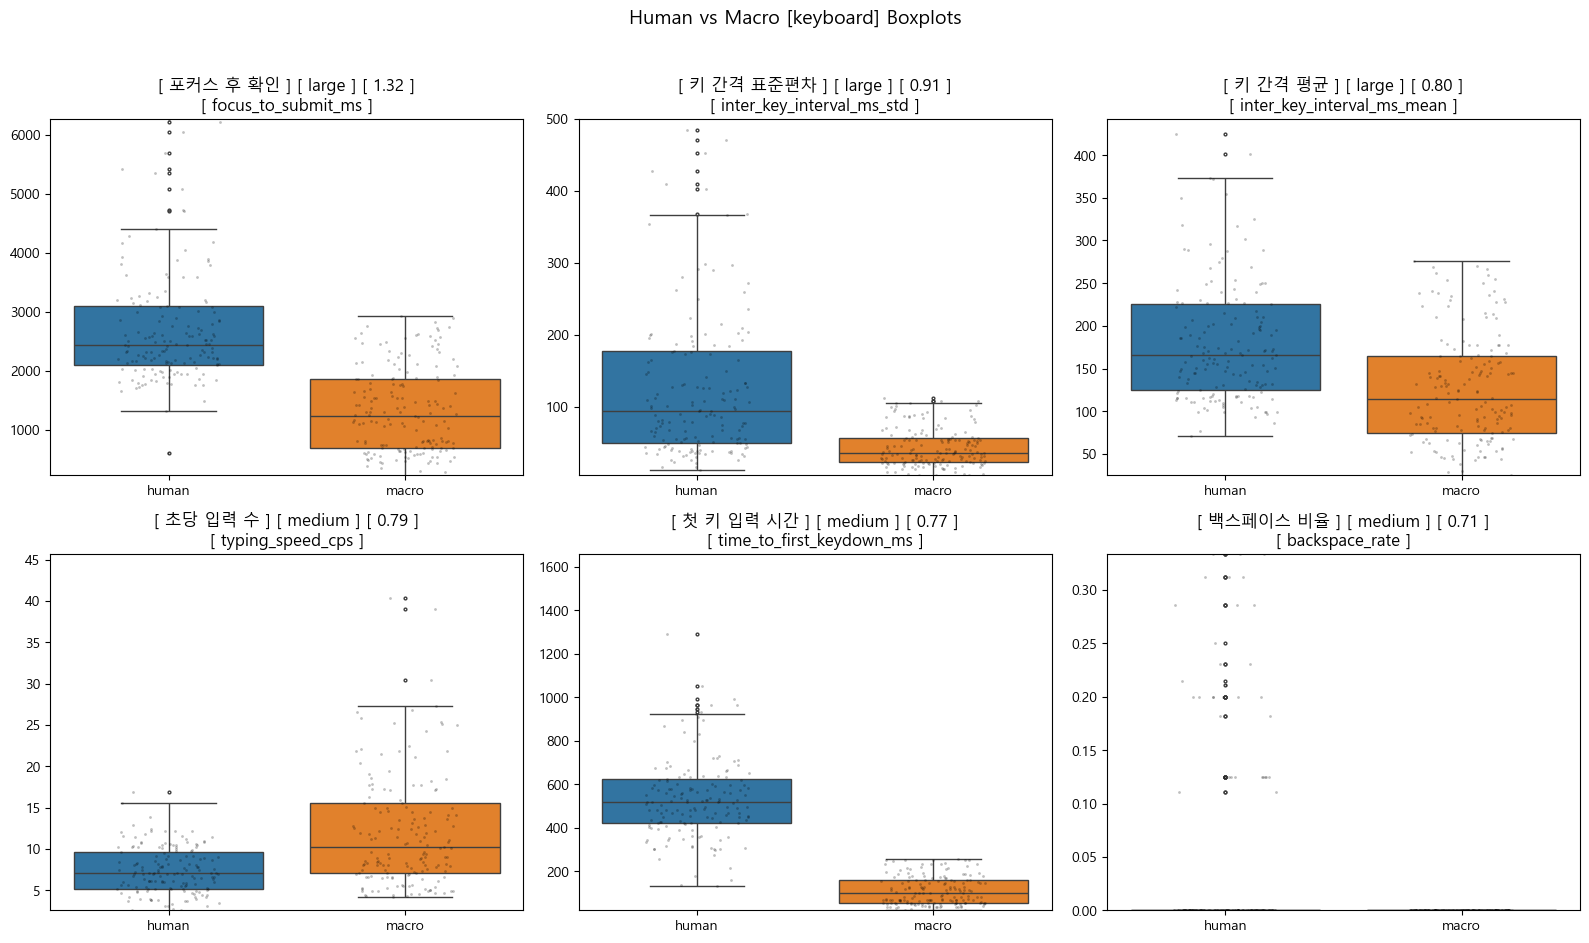

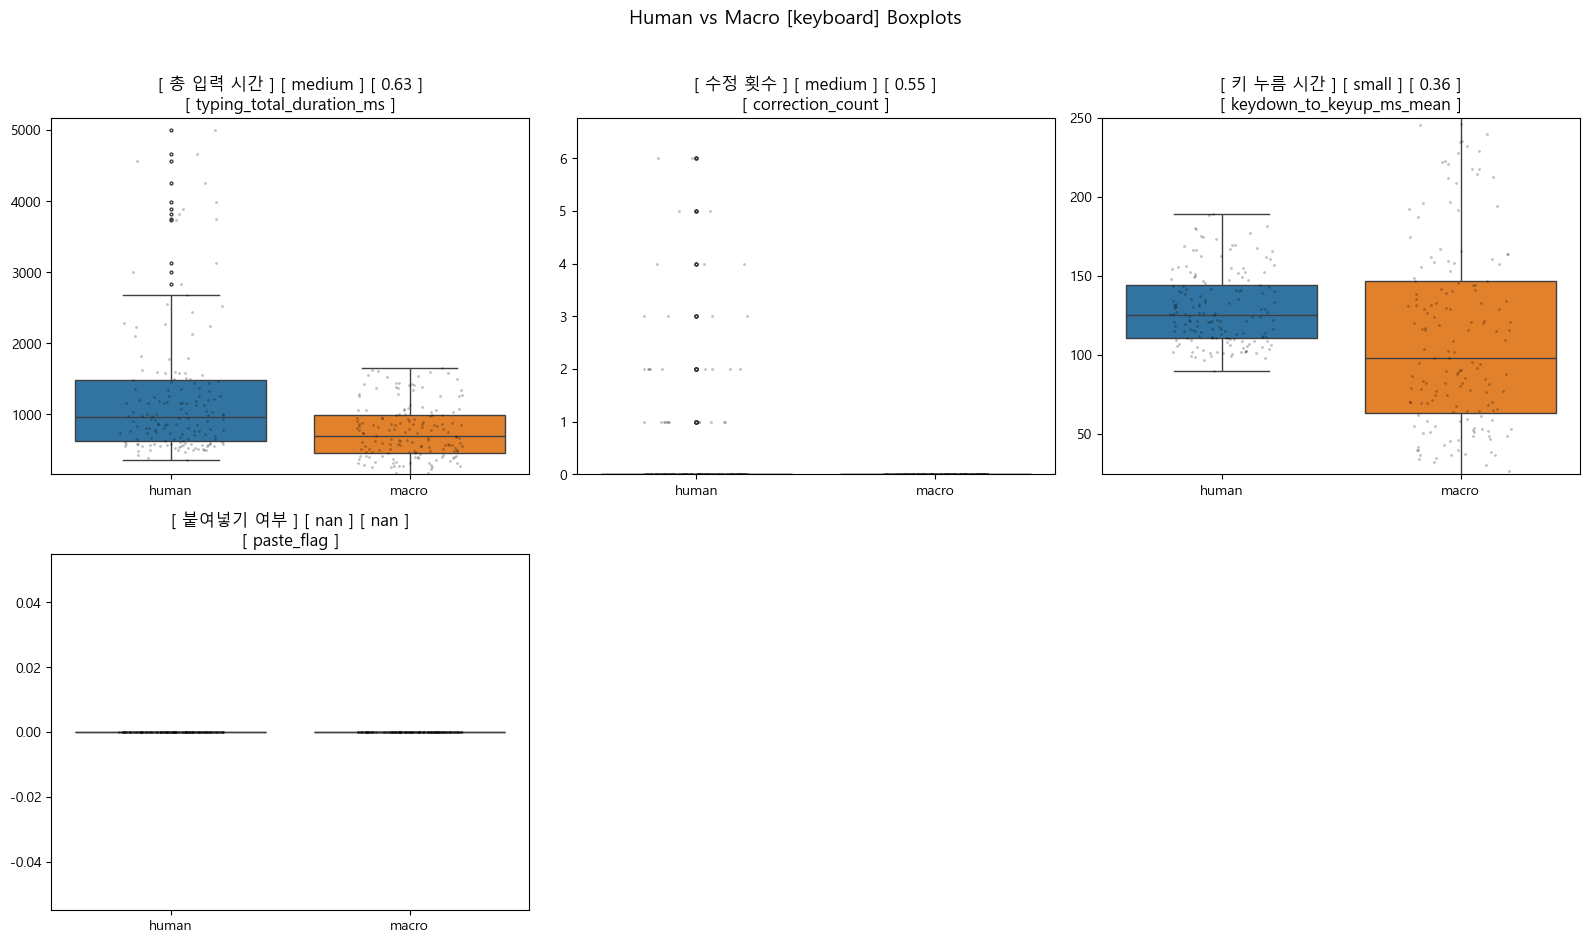

In [23]:
print("\n3. 그룹:", groups[2])
draw_boxplot(groups[2], features_list[2])

(comment)

키보드에는 huge, very_large 그룹이 없고 클릭, 마우스 feature보다 우선순위 낮음

> 결론

- 휴먼과 매크로 행동 데이터의 차이가 큰 huge, very_large만을 우선 차용하고 성능이 부족하면 large 그룹 추가
- huge 그룹 중 지속적으로 차이가 명확한 feature는 알고리즘적 필터링으로 전환
- 상관관계 분석을 통해 강한 상관관계를 가지는 feature들의 중복 제거 여부 분석 필요

### 3-2 상관관계 분석

(comment)

- 상관관계 0.9 이상의 feauture 그룹은 SMD 가장 높은 feature만 제외하고 제거
- 0.7 ~ 0.9의 강한 상관관계 그룹은 제거 후보로 기록

In [24]:
level_color_map = {
    "huge": "red",
    "very_large": "darkorange",
}

ko_feature_map = {
    ko: feature
    for feature, ko in FEATURE_NAME_KR.items()
}

def highlight_smd_level_ticks(ax, ko_feature_map: dict, feature_smd_map: dict, level_color_map: dict) -> None:
    """heatmap tick label을 SMD level 기준으로 강조"""

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        feature_ko = tick.get_text()
        feature = ko_feature_map.get(feature_ko)

        level, abs_smd = feature_smd_map.get(feature, (None, np.nan))

        if pd.isna(level):
            continue

        level = str(level)

        if level in level_color_map:
            tick.set_color(level_color_map[level])
            tick.set_fontweight("bold")

In [25]:
def draw_heatmap(group: str, features: list[str]) -> None:
    """행동 feature 그룹별 feature 간 상관관계 heatmap 그리기
    
    Args:
        group (str): feature 그룹명
        features (list[str]): feature 이름 리스트
    """

    features =  [feature for feature in features if feature not in EXCLUDE_COL]

    if not features:
        print("skip:", group)
        return

    corr_df = df[features].apply(pd.to_numeric, errors="coerce").corr()

    corr_df = corr_df.rename(
        index=FEATURE_NAME_KR,
        columns=FEATURE_NAME_KR
    )

    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.xticks(rotation=45, ha="right")

    highlight_smd_level_ticks(
        ax=ax,
        ko_feature_map=ko_feature_map,
        feature_smd_map=feature_smd_map,
        level_color_map=level_color_map,
    )

    plt.title(f"[ {group} ] Feature Correlation Heatmap")
    plt.show()




1. 그룹: click


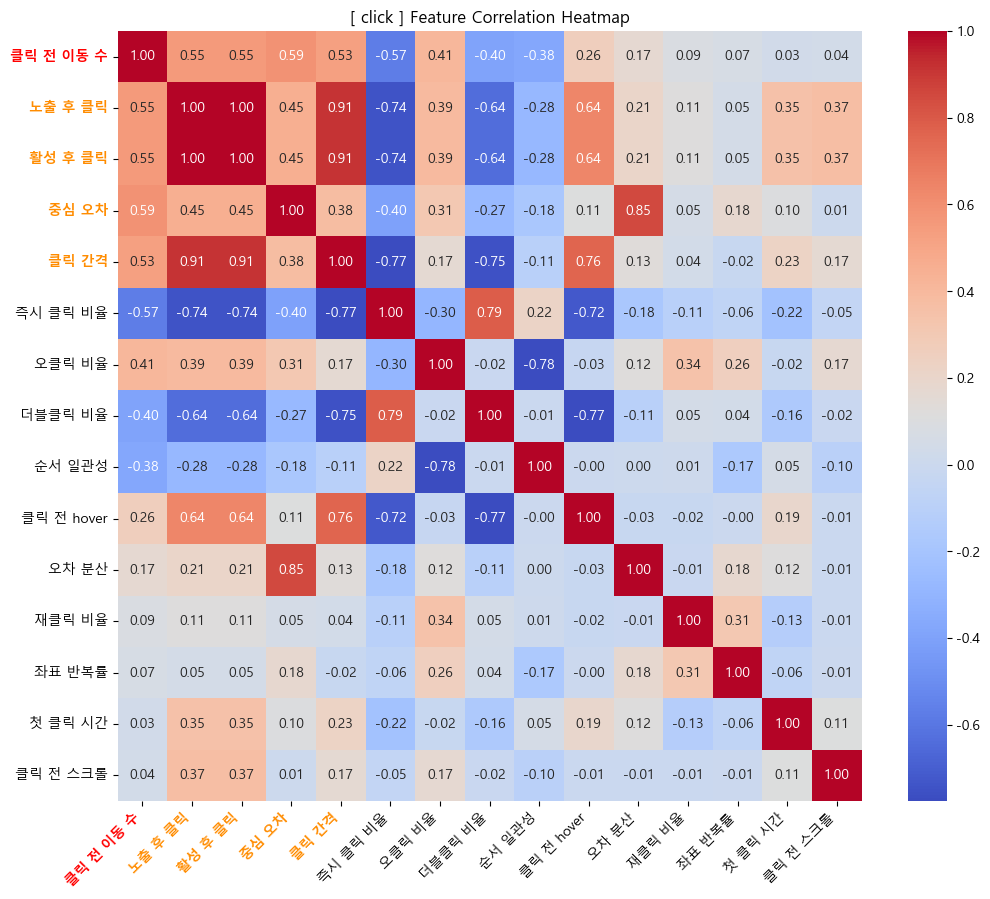

In [26]:
print("\n1. 그룹:", groups[0])
draw_heatmap(groups[0], features_list[0])

(comment)

huge, very_large 그룹 feature 상관관계 분석 (click)

- 0.9 이상
    - 노출 후 클릭, 활성화 후 클릭 (1.00) : 아주 강한 상관관계를 보임 -> SMD 지표 동일하므로 `노출 후 클릭`만 선택
    - 노출 후 클릭, 클릭 간격 (0.91) : 강한 상관관계를 보임 -> 클릭 간격은 수집 보류 상태이므로 일단 보류



2. 그룹: mouse


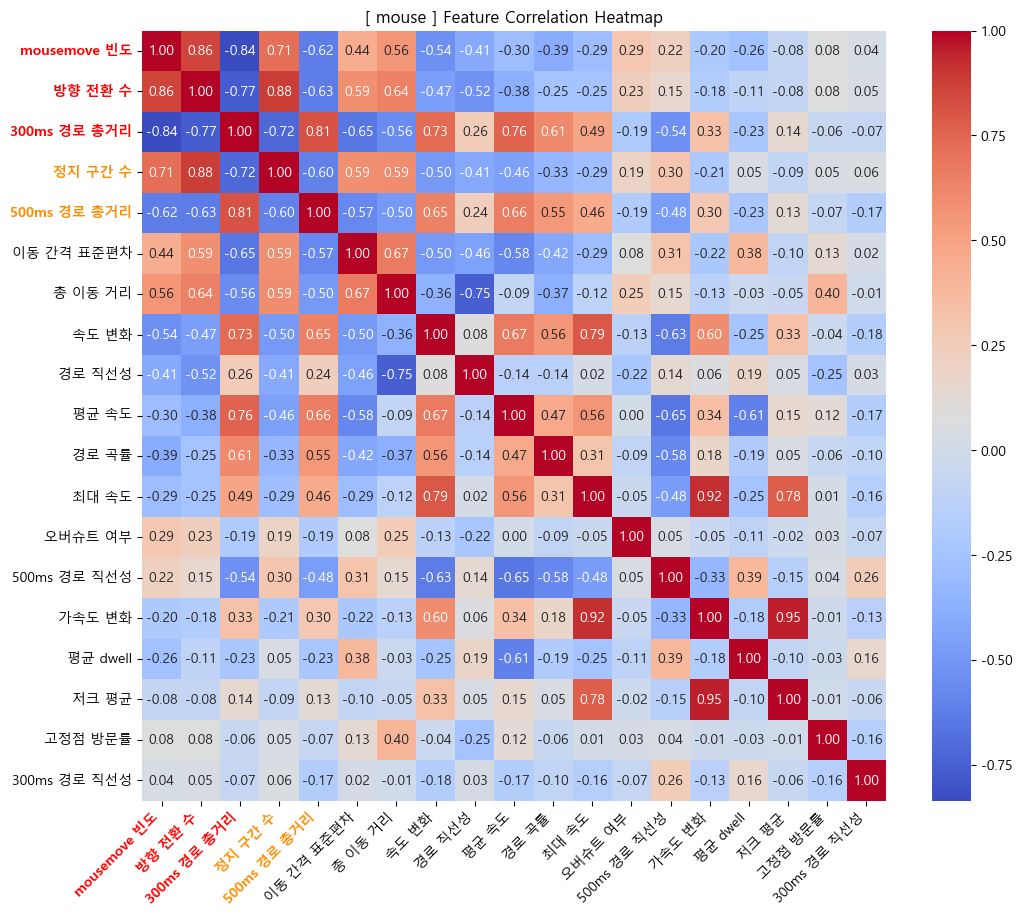

In [27]:
print("\n2. 그룹:", groups[1])
draw_heatmap(groups[1], features_list[1])

(comment)

huge, very_large 그룹 feature 상관관계 분석 (mouse)

- 0.7 ~ 0.9 : feature 많을 시 제거 후보 등록
    - mouse feature의 huge, very_large 그룹은 비교적 강한 상관관계를 보임



3. 그룹: keyboard


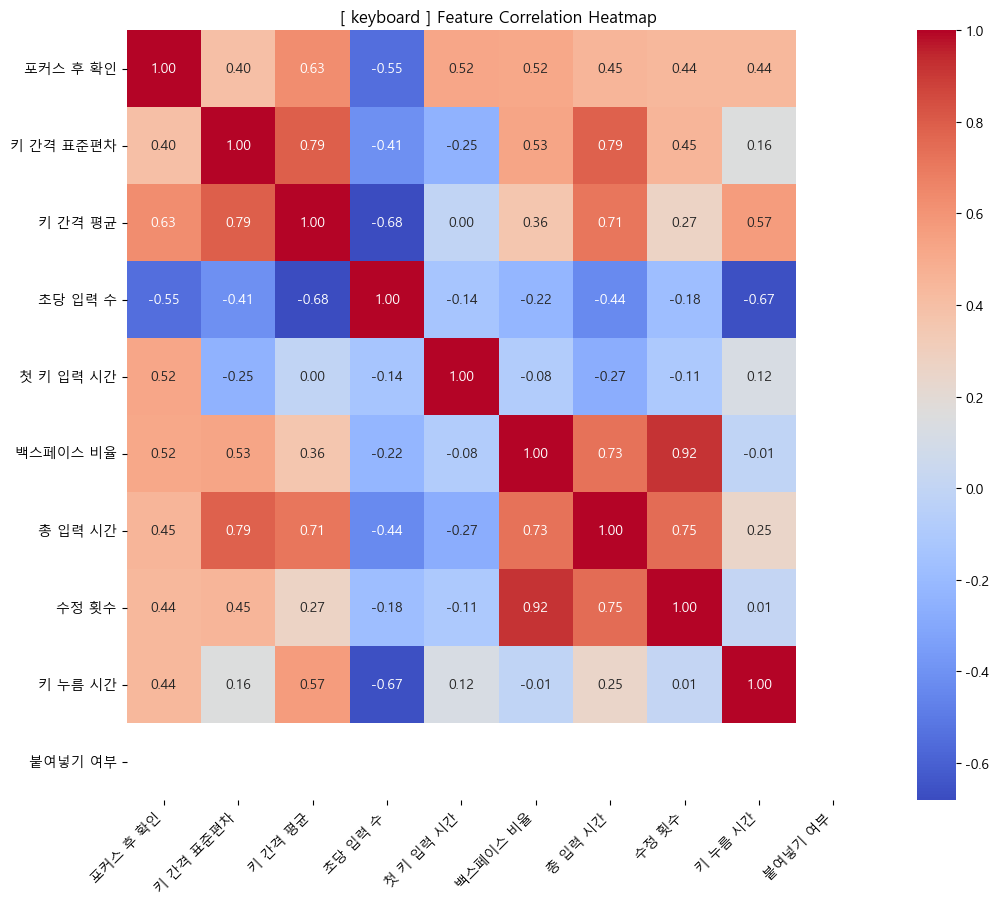

In [28]:
print("\n3. 그룹:", groups[2])
draw_heatmap(groups[2], features_list[2])

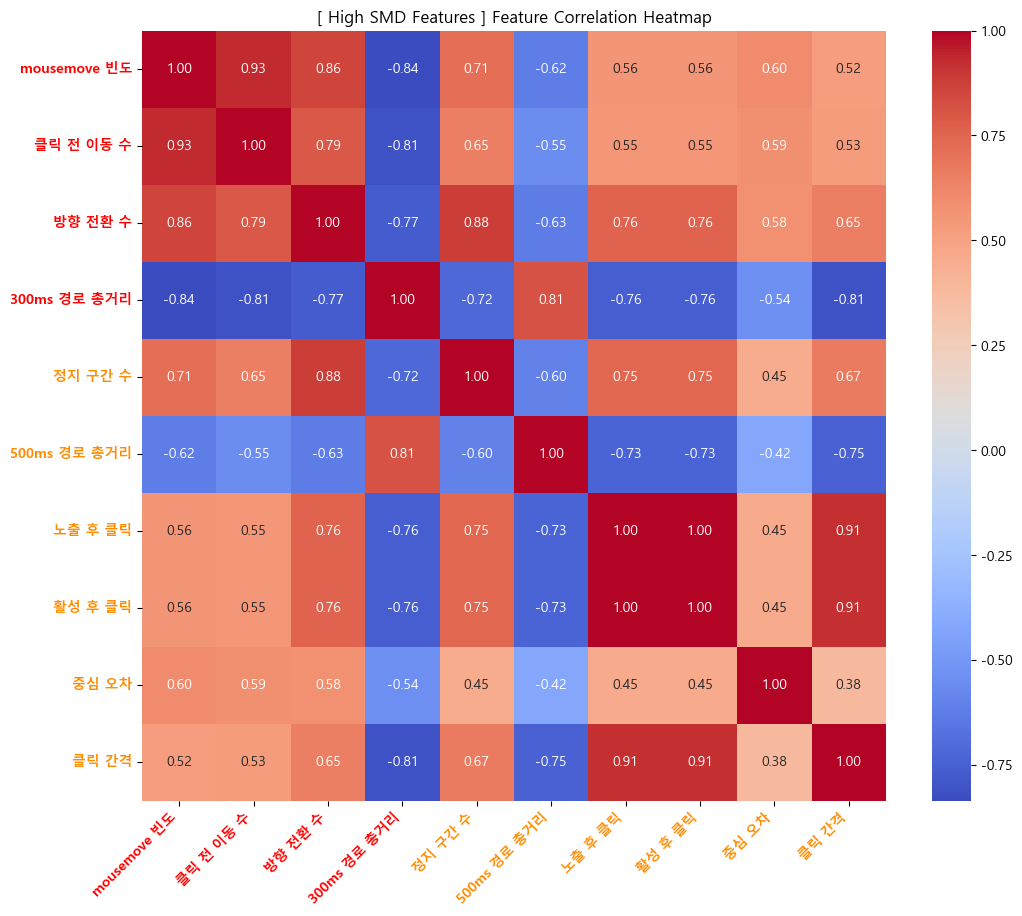

In [29]:
high_smd_features = [feature for feature, (level, abs_smd) in feature_smd_map.items() if level in ["huge", "very_large"] and feature_group_map.get(feature, "summary") != "summary"]

high_smd_features = sorted(
    high_smd_features,
    key=lambda feature: feature_smd_map[feature][1],
    reverse=True
)

draw_heatmap("High SMD Features", high_smd_features)

(comment)

- mousemove 빈도, 클릭 전 이동 수, 방향 전환 수 중 1~2개
- 노출 후 클릭, 활성 후 클릭 중 노출 후 클릭 선택
- 나머지 차용이 초기 셋팅으로 좋아보임

### 3-3 PCA

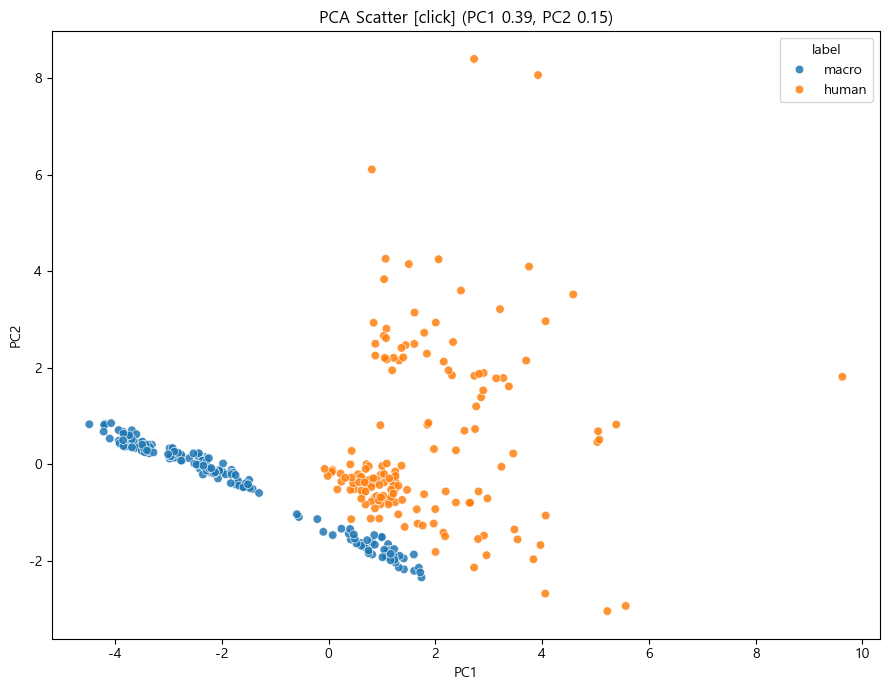

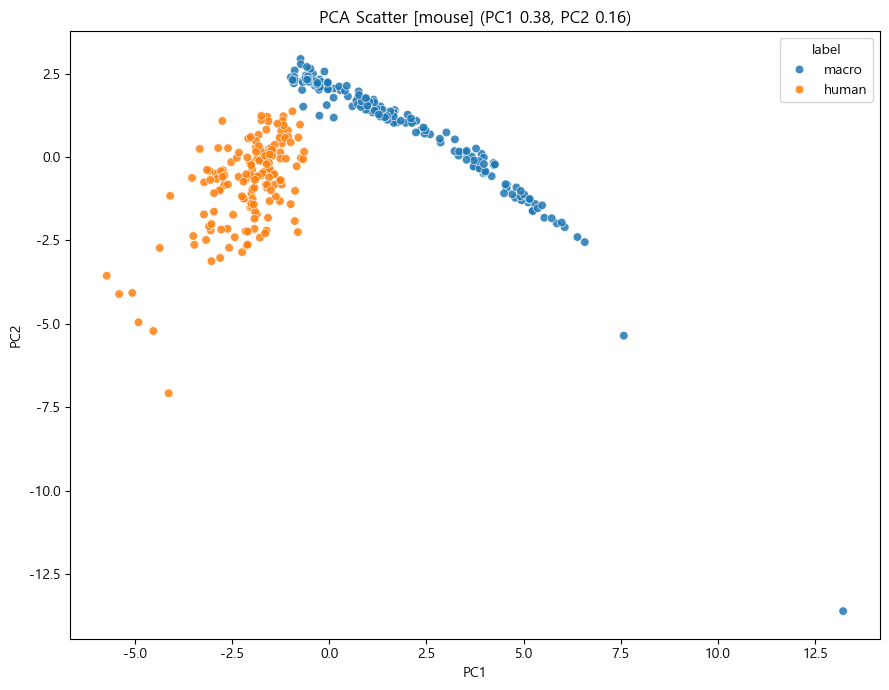

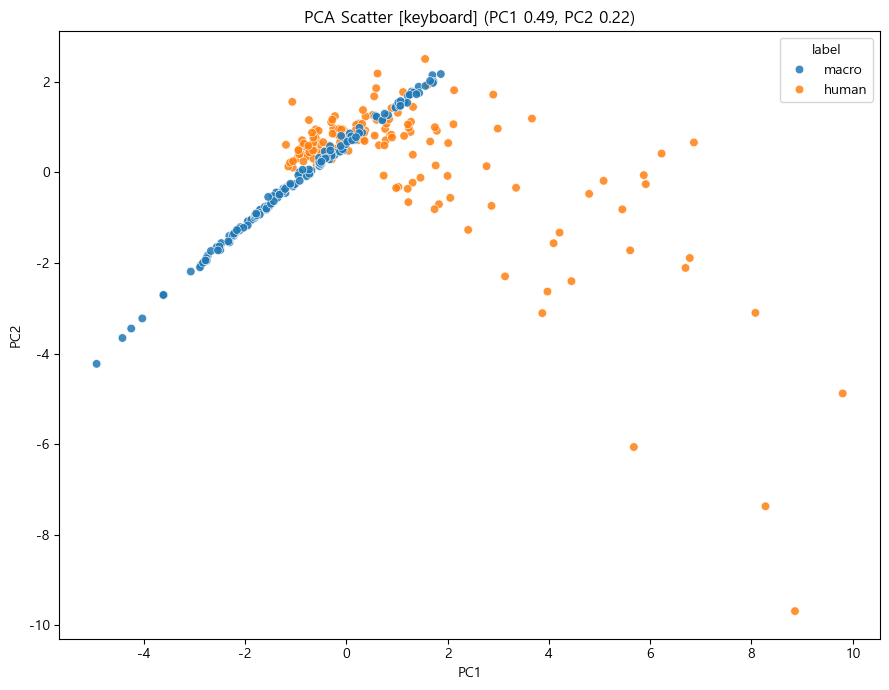

In [30]:
def draw_pca_scatter(title: str, features: list[str]) -> None:
    """PCA scatter plot 그리기
    
    Args:
        title (str): plot 제목
        features (list[str]): PCA에 사용할 feature 이름 리스트
    """

    features = [feature for feature in features if feature not in EXCLUDE_COL]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = df[features].apply(pd.to_numeric, errors="coerce")

    features = [feature for feature in features if X[feature].notna().sum() > 0]

    if len(features) < 2:
        print("skip PCA:", title)
        return

    X = X[features]

    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=2, random_state=42)),
        ]
    )

    xy = pipe.fit_transform(X)
    pca = pipe.named_steps["pca"]
    explained = pca.explained_variance_ratio_

    plt.figure(figsize=(9, 7))

    sns.scatterplot(
        x=xy[:, 0],
        y=xy[:, 1],
        hue=df["label"],
        s=38,
        alpha=0.85,
    )

    plt.title(
        f"PCA Scatter [{title}] "
        f"(PC1 {explained[0]:.2f}, PC2 {explained[1]:.2f})"
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

for group, features in FEATURE_GROUPS.items():
    draw_pca_scatter(group, features)

(comment)

- click, mouse 그룹의 feature는 차이가 뚜렷함
- keyboard feature만으로는 구분이 어려운 것을 볼 수 있음

44


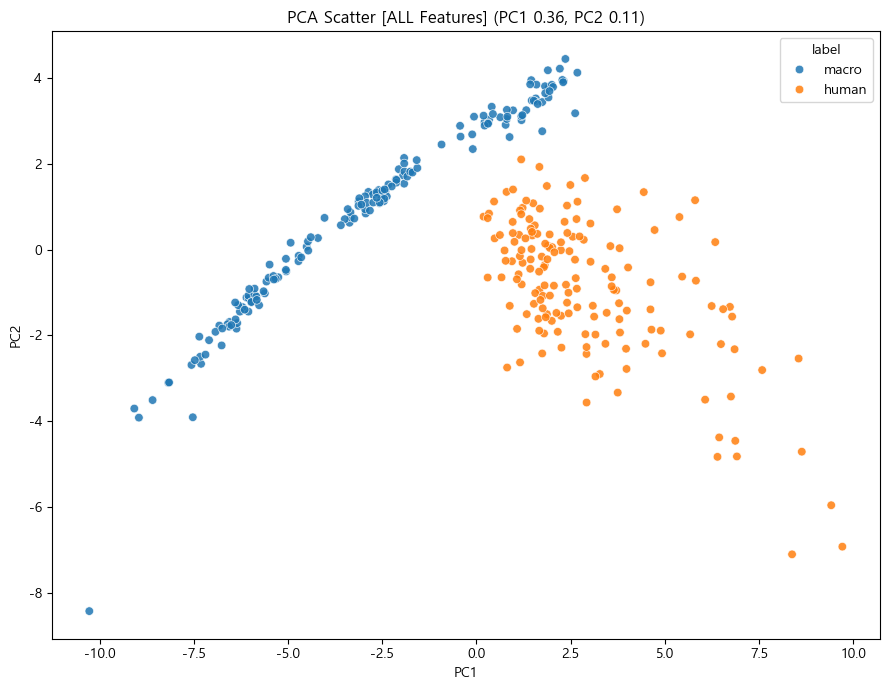

In [31]:
all_features = features_list[0] + features_list[1] + features_list[2]
print(len(all_features))

draw_pca_scatter(
    title="ALL Features",
    features=features_list[0] + features_list[1] + features_list[2]
)

(comment)

- 44개 feature를 전부 썼을 때 구분이 뚜렷한 것을 알 수 있지만 비용이 큼

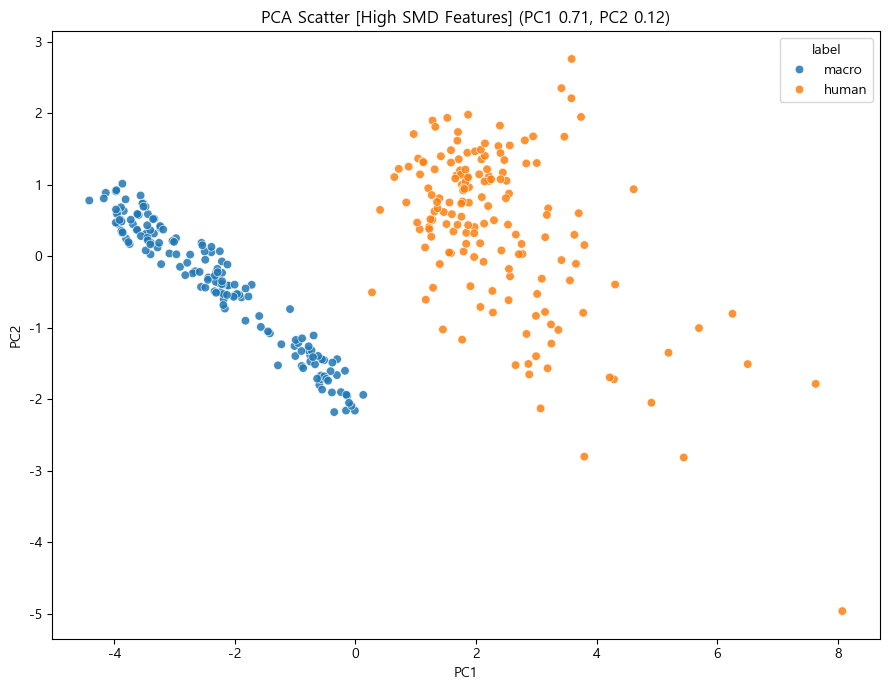

In [32]:
draw_pca_scatter(
    title="High SMD Features",
    features=high_smd_features,
)

In [33]:
print(high_smd_features)

['mousemove_event_rate', 'pre_click_mousemove_count', 'mouse_direction_change_count', 'pre_click_path_300ms_total_distance_px', 'mouse_stop_segment_count', 'pre_click_path_500ms_total_distance_px', 'time_from_element_visible_to_click_ms', 'time_from_element_clickable_to_click_ms', 'click_offset_from_element_center_px', 'inter_click_interval_ms']


(comment)

- SMD 값이 높은 huge, very_large 그룹만 사용해도 휴먼과 매크로 분리가 잘 되는 것을 볼 수 있음 (10개) (click, mouse만 포함)
- 초기 실험 : 10개의 feature로 ML 실험을 진행 -> 성능 파악
    - 성능 부족 -> large 그룹 feature 세부 EDA 진행 후 추가
    - 성능 좋음 -> SMD, 상관관계 기준 feature 감소 계획 진행

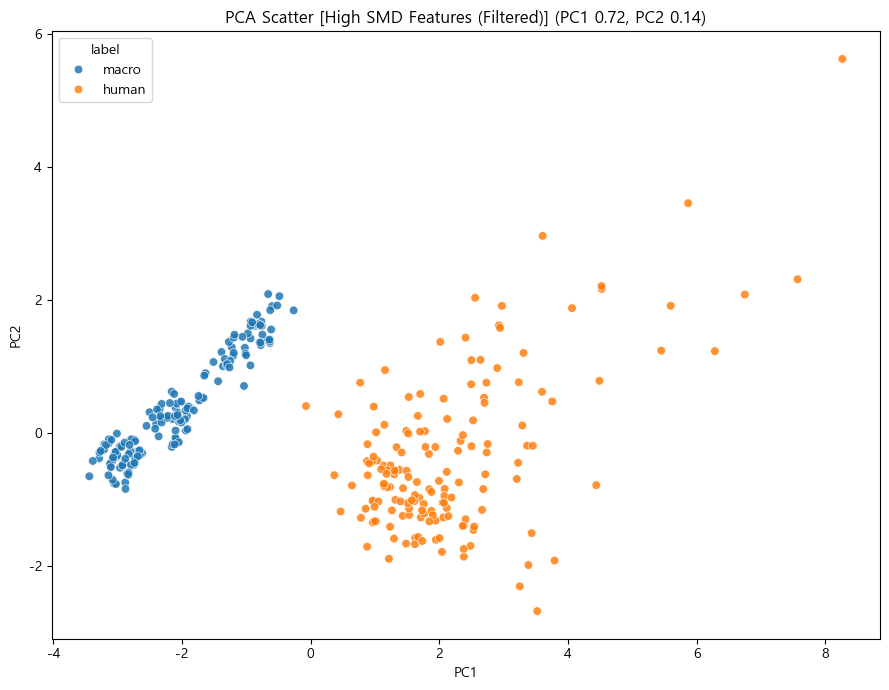

In [35]:
# 전처리 필요한 feature 제외하고 PCA

high_smd_features_filtered = [
    feature
    for feature in high_smd_features
    if feature not in ["pre_click_path_300ms_total_distance_px", "pre_click_path_500ms_total_distance_px"]
]

draw_pca_scatter(
    title="High SMD Features (Filtered)",
    features=high_smd_features_filtered,
)

(comment)

["pre_click_path_300ms_total_distance_px", "pre_click_path_500ms_total_distance_px"]
- 전처리 필요한 feature PCA 영향도 큼